##  Identity Aware Residual Probing

In the second extension of the Chronos paper, we apply Identity-Aware Residual Probing. Based on the analysis from Extension 1, we obtained valuable insights using the K-means clustering algorithm on aggregated data. The results indicate that shops in the Rossmann dataset can be grouped into different regimes, which we interpret as distinct identities.

This observation motivates us to enrich the representation of each shop by introducing cluster embeddings. These embeddings capture shared characteristics of similar shops by integrating common information into a unified embedding space.

Rather than modifying the Chronos architecture, we introduce a residual correction head that operates on top of Chronos predictions. The residual head outputs a vector of residual corrections corresponding to the forecasted time steps (and their quantiles). This design allows identity-aware specialization through a small, efficient correction module.

## Clustering Methodology

Clustering methodology follows UMAP - HDBSCAN pipeline + soft clustering assignements. For UMAP settings we used fixed default settings. While for HDBSCAN, we tested different settings:


In [1]:
import pandas as pd

df = pd.DataFrame([
    ["S1_base", 10, 2, "euclidean", "eom", "Baseline – balanced density sensitivity"],
    ["S2_more_strict_density", 10, 5, "euclidean", "eom", "Stricter density → more noise, purer cores"],
    ["S3_larger_min_cluster", 20, 2, "euclidean", "eom", "Coarser segmentation → macro clusters"],
    ["S4_leaf_granular", 10, 2, "euclidean", "leaf", "Fine-grained segmentation (over-segmentation check)"],
    ["S5_high_density_strict", 20, 5, "euclidean", "eom", "Very conservative clustering (stress test)"],
], columns=[
    "Scenario", "min_cluster_size", "min_samples", 
    "metric", "cluster_selection_method", "Description"
])

df

,Scenario,min_cluster_size,min_samples,metric,cluster_selection_method,Description
0,S1_base,10,2,euclidean,eom,Baseline – balanced density sensitivity
1,S2_more_strict_density,10,5,euclidean,eom,"Stricter density → more noise, purer cores"
2,S3_larger_min_cluster,20,2,euclidean,eom,Coarser segmentation → macro clusters
3,S4_leaf_granular,10,2,euclidean,leaf,Fine-grained segmentation (over-segmentation c...
4,S5_high_density_strict,20,5,euclidean,eom,Very conservative clustering (stress test)


After running clusterization pipeline, results are summarized:

In [5]:
import os 
print(os.getcwd())


c:\Users\mb-com.me\Desktop\chronos\chronos-2-dnlp\notebooks


In [ ]:
SCENARIOS_PATH = "../data/extension3/scenarios/scenario_comparison_summary.csv"

df = pd.read_csv(SCENARIOS_PATH)
scenarios = df["scenario"].tolist()
df = df.set_index("scenario")
df



,n_points,n_clusters_core,noise_core,noise_core_ratio,max_cluster_core,mean_prob_core,mean_persistence_core_w,min_cluster_size,min_samples,cluster_selection_method,outliers_final,outliers_final_ratio,assigned_soft,core_plot_path,final_plot_path
scenario,,,,,,,,,,,,,,,
S5_high_density_strict,748,5,40,0.053476,246,0.882279,0.267467,20,5,eom,0,0.0,40,data/extension3/scenarios\S5_high_density_stri...,data/extension3/scenarios\S5_high_density_stri...
S3_larger_min_cluster,748,3,1,0.001337,371,0.960718,0.222543,20,2,eom,0,0.0,1,data/extension3/scenarios\S3_larger_min_cluste...,data/extension3/scenarios\S3_larger_min_cluste...
S2_more_strict_density,748,7,57,0.076203,356,0.975437,0.170362,10,5,eom,0,0.0,57,data/extension3/scenarios\S2_more_strict_densi...,data/extension3/scenarios\S2_more_strict_densi...
S4_leaf_granular,748,26,208,0.278075,57,0.894712,0.143978,10,2,leaf,0,0.0,208,data/extension3/scenarios\S4_leaf_granular\plo...,data/extension3/scenarios\S4_leaf_granular\plo...
S1_base,748,5,12,0.016043,356,0.986575,0.139790,10,2,eom,0,0.0,12,data/extension3/scenarios\S1_base\plots\S1_bas...,data/extension3/scenarios\S1_base\plots\S1_bas...


### **Clustering Scenarios Analysis**

#### S1_base
**Parameters:** min_cluster_size = 10, min_samples = 2, cluster_selection_method = eom

This scenario produces five clusters with a very low noise ratio (1.6%). It achieves the highest mean membership probability (0.987), indicating that data points are assigned to clusters with very high confidence. Cluster persistence is moderate but stable, and cluster sizes are well balanced.

**Interpretation:**  
This configuration provides the best balance between cluster compactness, stability, and interpretability.

#### S2_more_strict_density
**Parameters:** min_cluster_size = 10, min_samples = 5, cluster_selection_method = eom

This configuration yields seven clusters and a higher noise ratio (7.6%). While membership probabilities remain high, the stricter density requirement causes a larger number of points to be classified as noise and leads to increased cluster fragmentation.

**Interpretation:**  
This scenario is useful for identifying dense core structures but is too restrictive for a general clustering solution.

### S3_larger_min_cluster
**Parameters:** min_cluster_size = 20, min_samples = 2, cluster_selection_method = eom

This scenario produces three large clusters with almost no noise (0.13%). It achieves a high weighted persistence score, indicating very stable clusters, but at the expense of reduced granularity.

**Interpretation:**  
This configuration captures the macro-structure of the data but does not provide sufficient detail for fine-grained analysis.

### S4_leaf_granular
**Parameters:** min_cluster_size = 10, min_samples = 2, cluster_selection_method = leaf

This scenario results in 26 clusters and a very high noise ratio (27.8%). Both membership probability and persistence are lower, and the resulting clusters are small and highly fragmented.

**Interpretation:**  
This configuration represents a clear case of over-segmentation and is not suitable for meaningful interpretation.

### S5_high_density_strict
**Parameters:** min_cluster_size = 20, min_samples = 5, cluster_selection_method = eom

This configuration yields five clusters with a higher noise ratio (5.3%) and the highest persistence score. However, the mean membership probability is noticeably lower, indicating reduced cluster compactness.

**Interpretation:**  
This scenario produces very stable but overly conservative clusters and is best suited as a stress test rather than a final clustering solution.


**FINAL SELECTION:** Based on this comparative analysis, S1_base is selected as the most appropriate clustering configuration for subsequent experiments. It provides the best trade-off between cluster stability, compactness, noise level, and interpretability, making it well suited for downstream analysis and meaningful cluster interpretation.


#### **UMAP Plot**

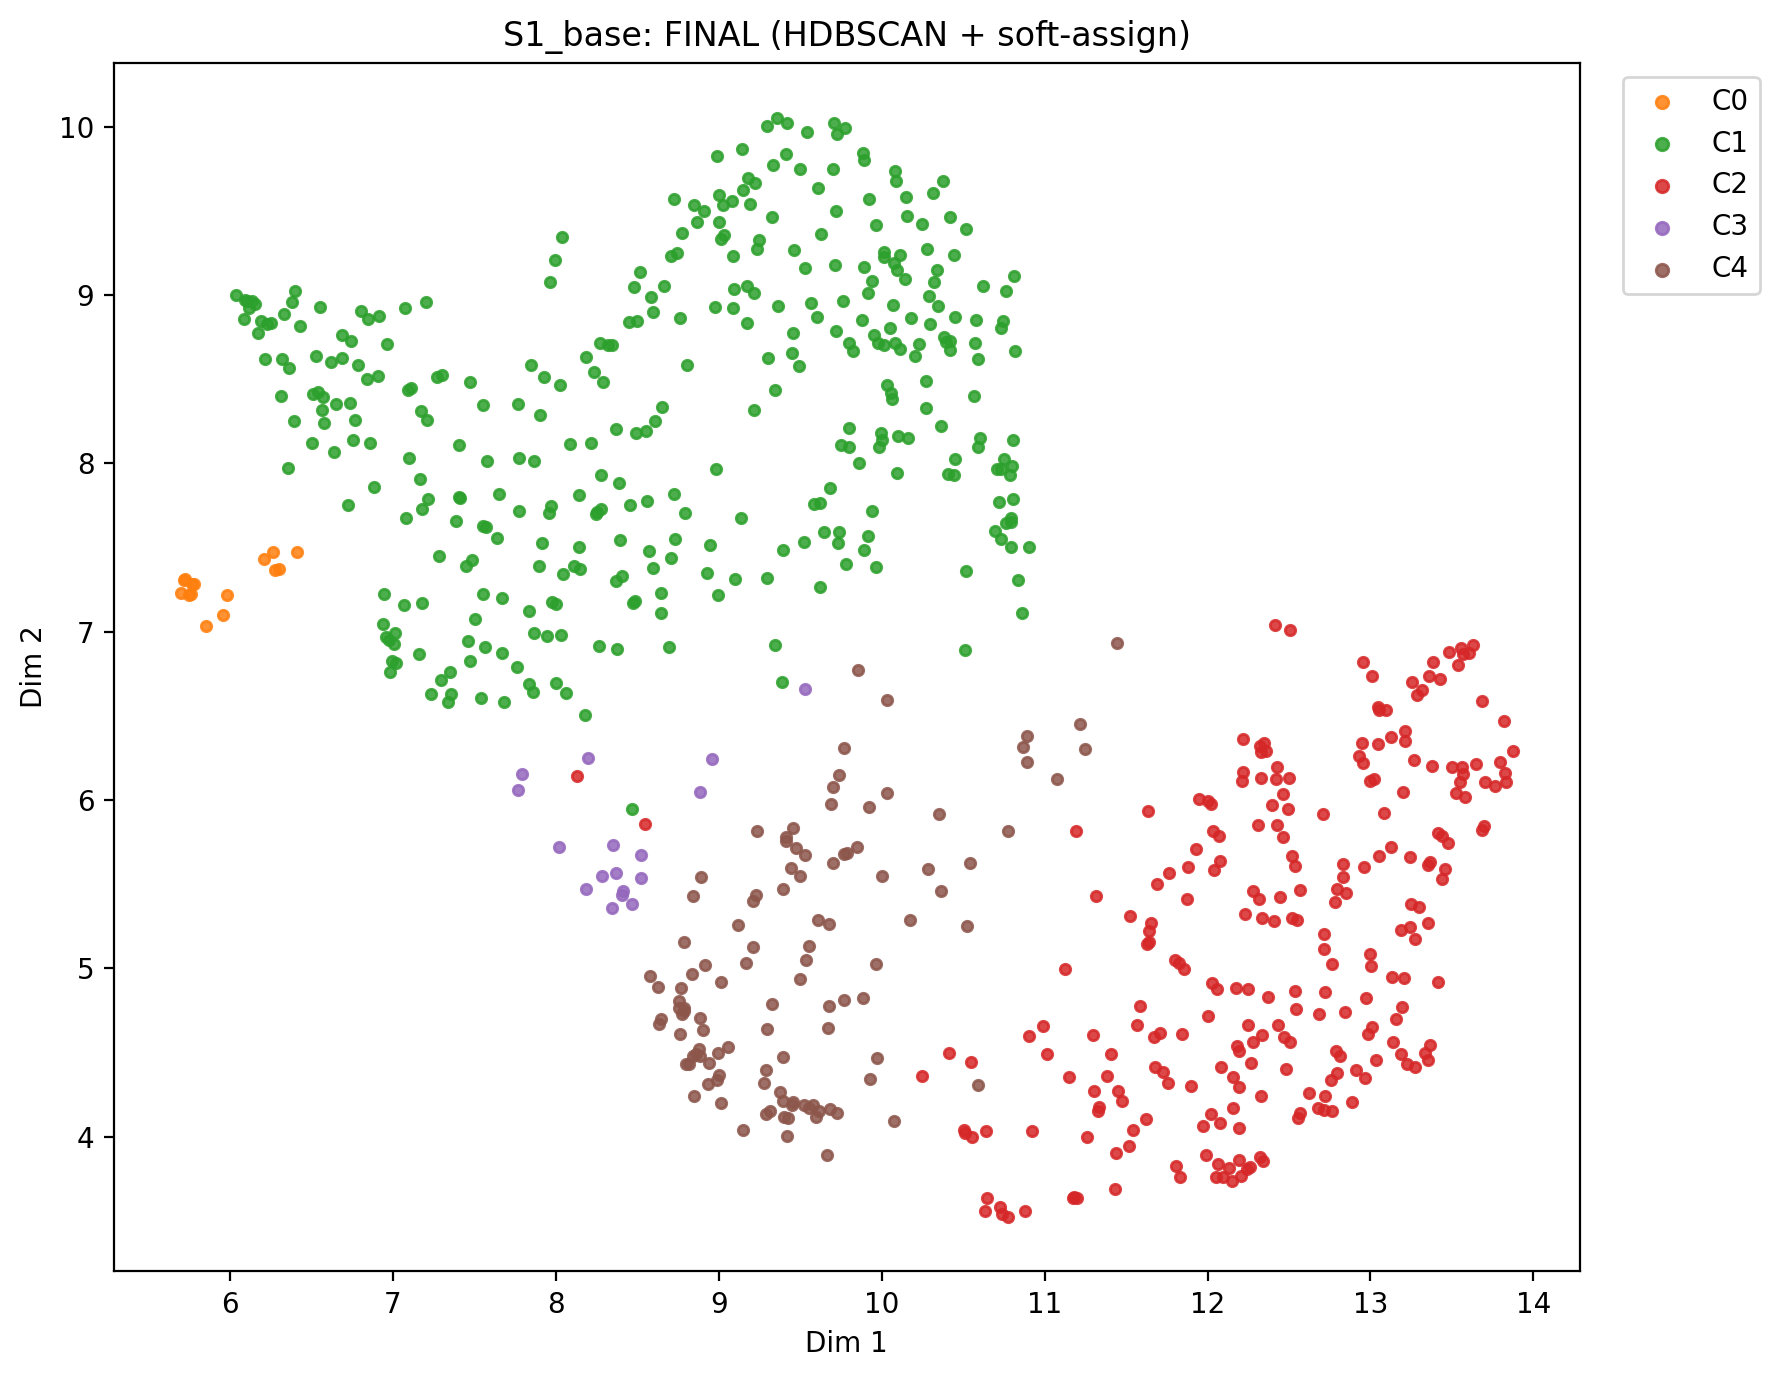

In [27]:
from IPython.display import Image, display

UMAP_PATH = "../data/extension3/scenarios/S1_base/plots/S1_base_final_labels.png"
display(Image(filename=UMAP_PATH))


This figure shows a projection of the data into UMAP space, where high-dimensional representations are mapped into two dimensions for visualization. It provides an intuitive visual overview of the clustering structure, illustrating how clusters are separated and how compact they are. Since this is a projection, it is intended for qualitative interpretation rather than precise quantitative analysis.


## Cluster Embedding Construction

After selecting the final clustering configuration, we construct a representative embedding for each cluster. For a given cluster, the cluster embedding is obtained by computing the mean of the shop embeddings assigned to that cluster.

Formally, let a cluster $ c $ contain a set of shops  
$\{s_1, \ldots, s_{N_c}\}$ with corresponding embeddings   $\{\mathbf{e}_{s_1}, \ldots, \mathbf{e}_{s_{N_c}}\}$.  
The cluster embedding is defined as:

$$
\mathbf{e}_c = \frac{1}{N_c} \sum_{i=1}^{N_c} \mathbf{e}_{s_i}
$$

This representation provides a compact summary of the common characteristics shared by shops within the same cluster.


### Residual Head

The Residual Head takes as input the shop embedding and the corresponding cluster embedding, which together encode both shop-specific and regime-level information. Its role is to predict residual corrections for quantile forecasts over the next 30 days. These residuals are added to the original Chronos quantile predictions, resulting in a recalibrated forecast that adjusts for systematic biases not captured by the base model.


## Training Settings

Training is performed using a supervised setup, where the target is defined as the difference between the ground-truth values and the base Chronos predictions.

The model is trained for **200 epochs** using the **AdamW optimizer** with a learning rate of **1e−3** and a weight decay of **1e−4**. Training is carried out on the available training shops, while test shops are held out for evaluation.

The loss function is the **pinball loss**, computed jointly over the **0.1, 0.5, and 0.9 quantiles** and over the full forecasting horizon. During training, predicted residuals are added to the original Chronos quantile forecasts, and **monotonicity constraints** are enforced to ensure valid quantile ordering (P10 ≤ P50 ≤ P90).



### Pinball Loss

The pinball loss is used for **quantile regression** and is defined, for a quantile level $ q \in (0,1) $, as:

$$
\mathcal{L}_q(y, \hat{y}) =
\begin{cases}
q \, (y - \hat{y}), & \text{if } y \ge \hat{y}, \\
(1 - q) \, (\hat{y} - y), & \text{otherwise}.
\end{cases}
$$

This asymmetric loss penalizes underestimation and overestimation differently, encouraging the model to learn the desired conditional quantile.


### Training Loss Results

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

loss_path = "outputs/extension2/train_loss_curve.npy"  # ili puni path
losses = np.load(loss_path)

plt.figure()
plt.plot(range(1, len(losses) + 1), losses)
plt.xlabel("Epoch")
plt.ylabel("Train Pinball Loss")
plt.title("Training Loss Curve")
plt.grid(True)
plt.show()

### Prediction Results on Test Data

In previous experiments, results were reported on the entire dataset, combining both training and test samples. In this section, the focus is exclusively on the test subset. To ensure a fair and consistent comparison, results from the baseline model and Extension 1 are re-evaluated and reported only on the test set, making them directly comparable with the results of the proposed extension.

The training dataset is used to fit both the clustering model and the residual head. Clustering is performed using embeddings extracted from the training shops, and the residual head is trained exclusively on training data, while the test set remains fully unseen and is used only for evaluation.



In [ ]:
RESULTS_ALL_TOGETHER_TEST = "../reports/wql_summary_all_together.csv"
df = pd.read_csv(RESULTS_ALL_TOGETHER_TEST)
df

,mode,mean,median,std,p25,p75,p90
0,ext2,0.0294,0.0277,0.0074,0.0240,0.0328,0.0402
1,ext1,0.0402,0.0398,0.0074,0.0348,0.0447,0.0487
2,baseline,0.0662,0.0645,0.0185,0.0462,0.0622,0.0765


### Visualizations

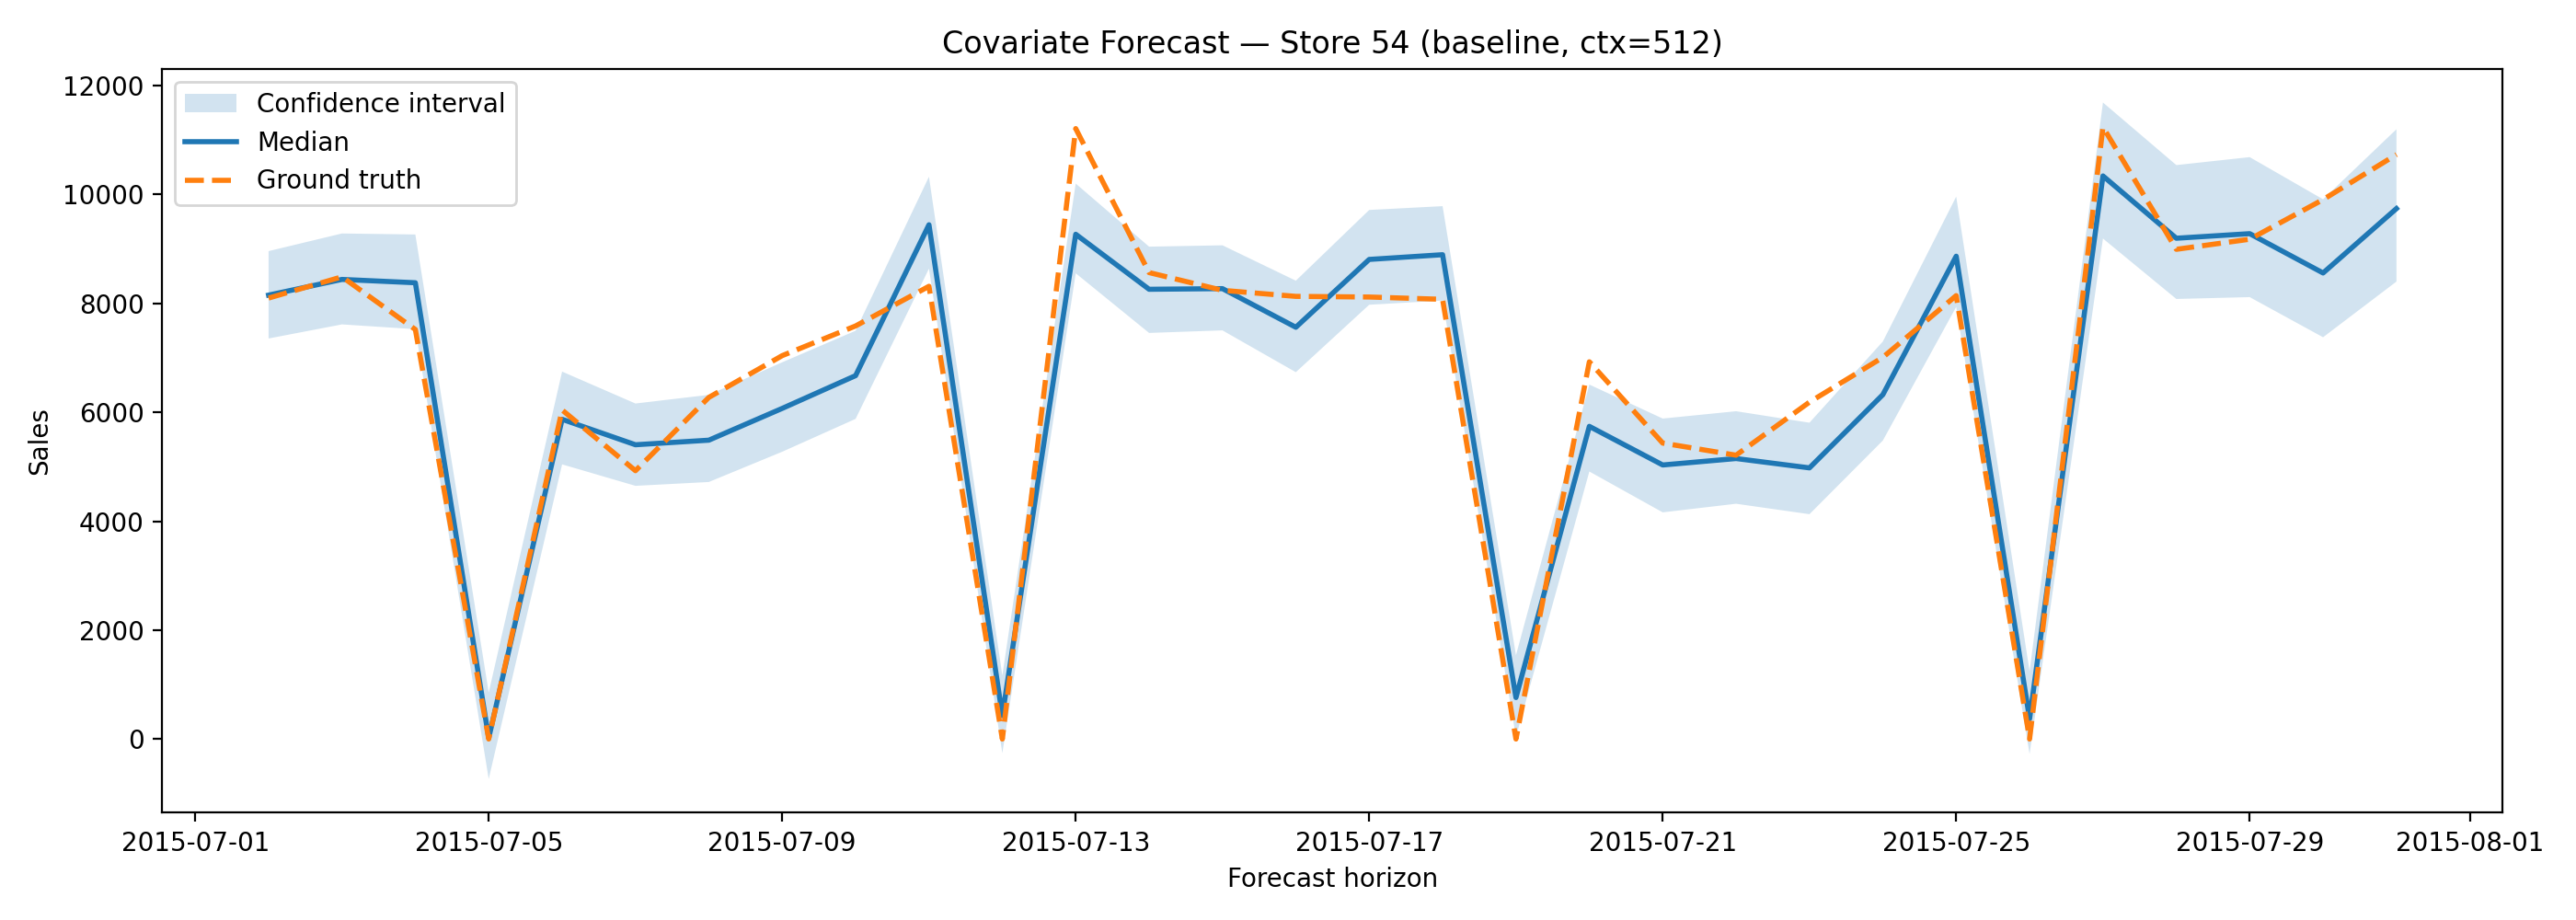

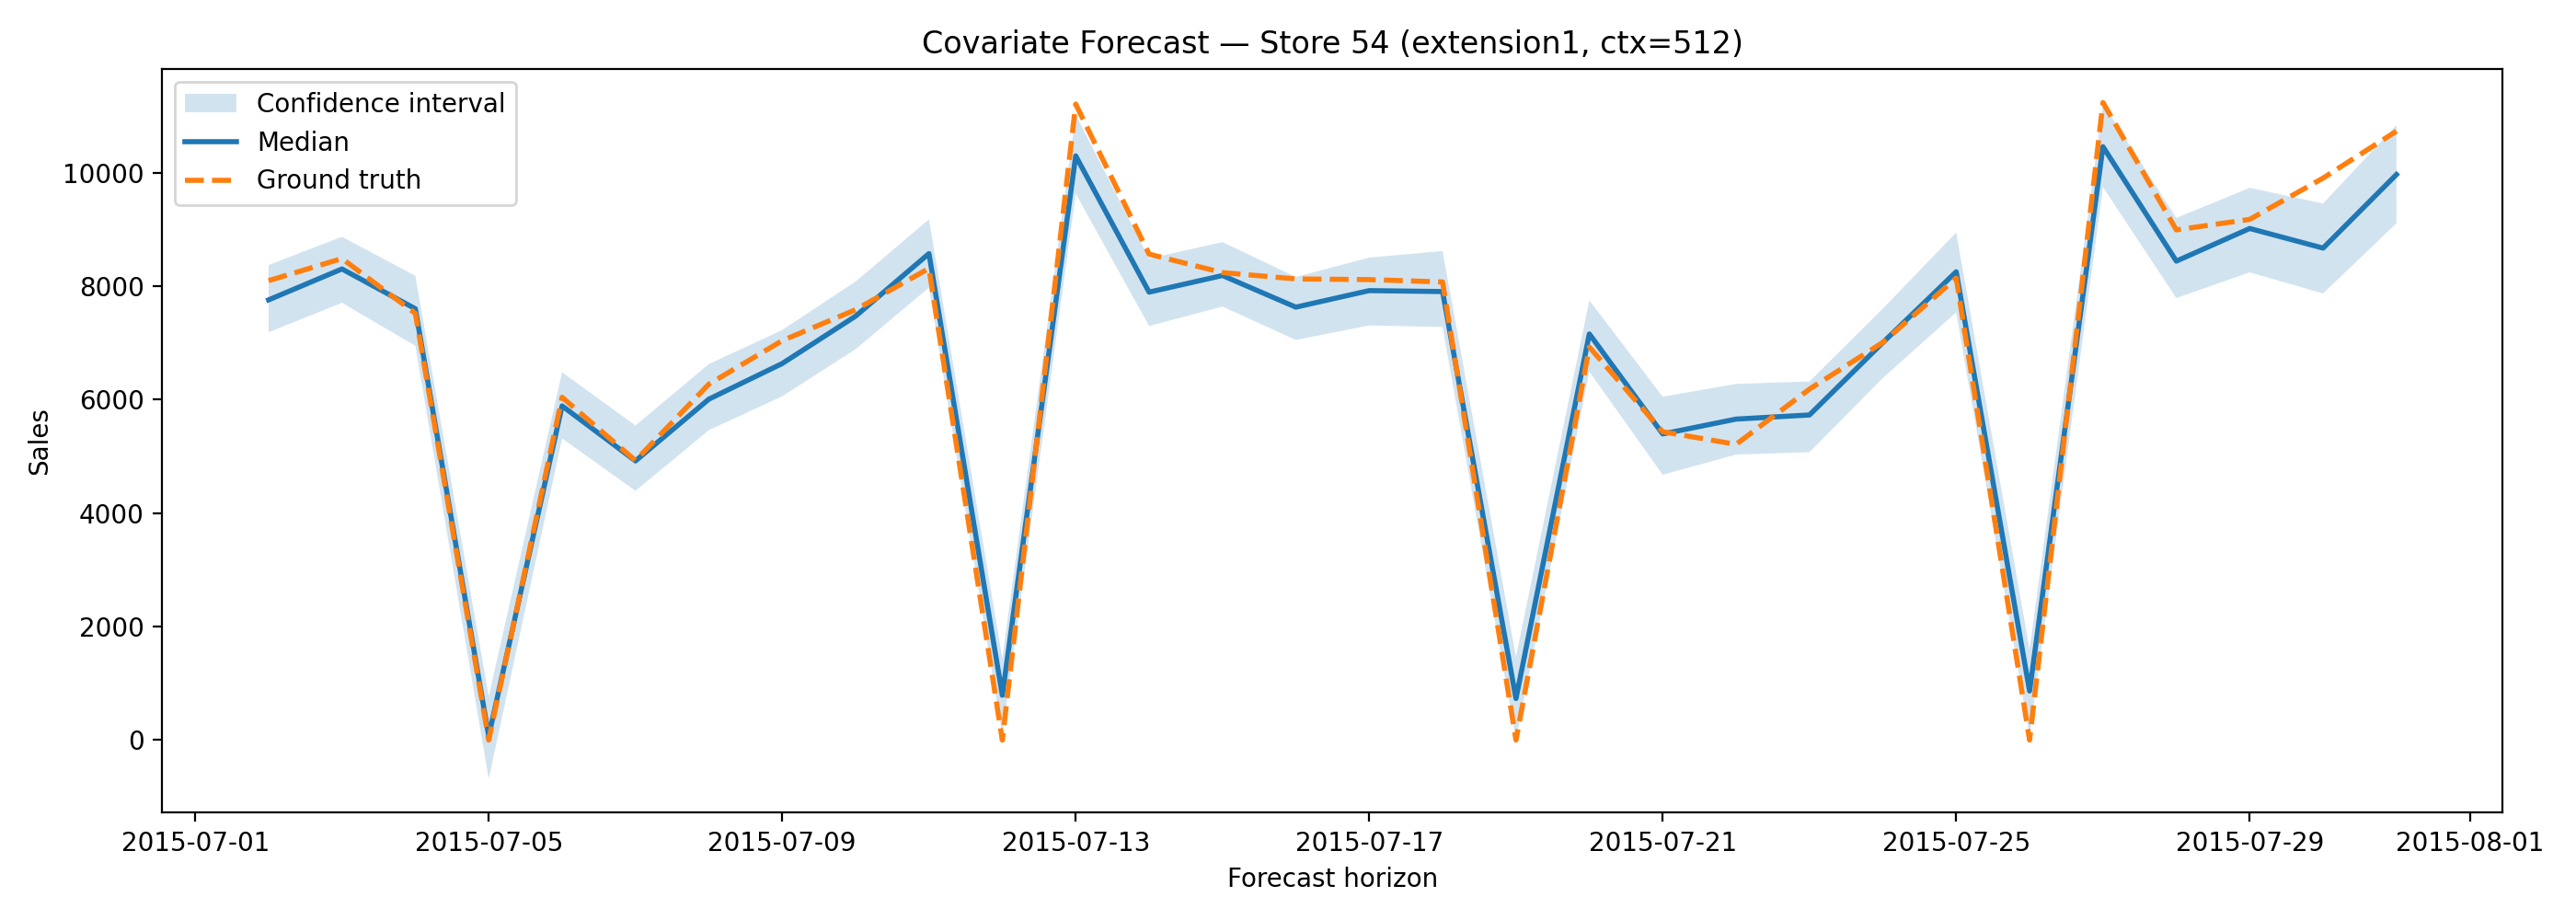

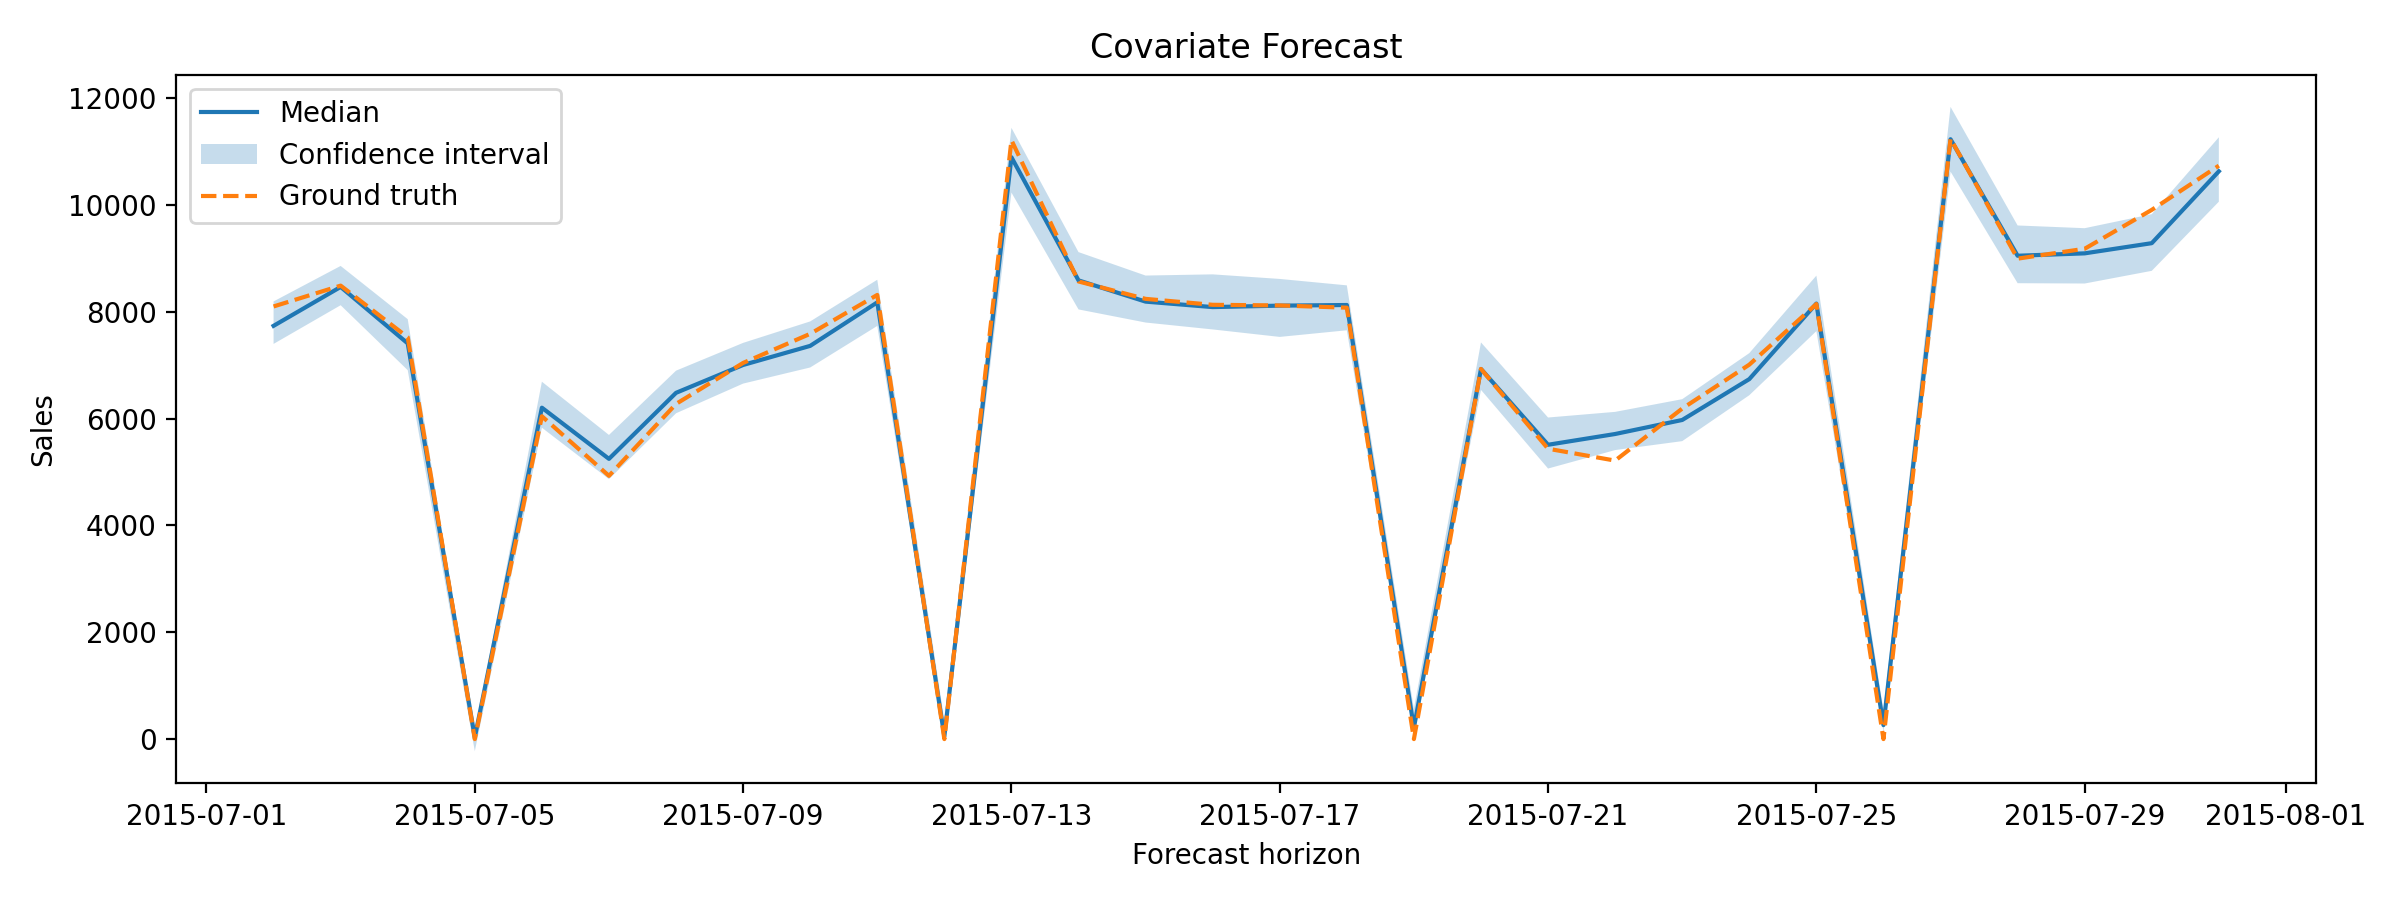

In [2]:
from IPython.display import Image, display

BASELINE_PATH = "../visualization/baseline/forecast_store_54.png"
EXT1_PATH = "../visualization/extension1/forecast_store_54.png"
EXT2_PATH = "../visualization/extension2/forecast_store_54.png"

display(Image(filename=BASELINE_PATH))
display(Image(filename=EXT1_PATH))
display(Image(filename=EXT2_PATH))

The results show a clear and consistent improvement across the three approaches. The baseline model has the highest mean and median WQL, as well as the largest standard deviation, indicating weaker performance and higher variability across stores.

Extension 1 substantially improves upon the baseline, reducing both the mean and median WQL while also achieving a lower variability. This suggests more accurate and more stable predictions compared to the baseline model.

Extension 2 achieves the best performance across all reported statistics. It has the lowest mean and median WQL, the tightest interquartile range, and the lowest values in the upper tail (p90). This indicates not only higher average accuracy but also improved robustness, with fewer extreme errors on difficult cases.

Overall, the results demonstrate a progressive improvement from the baseline to Extension 1 and further to Extension 2, confirming the effectiveness of the proposed extensions on the test set.